# AI-Generated Image Detection Baseline

This notebook implements a baseline deep learning pipeline for distinguishing real images from AI-generated images. The goal is to build a prototype image forensics framework using transfer learning with a pretrained ResNet50 model and evaluate its performance on a subset of the CIFAKE dataset.

## Step 1: Mount Google Drive

Google Drive is mounted so that datasets, trained models, figures, and result files can be stored persistently outside the temporary Colab runtime. This allows the experiment outputs to remain available even if the notebook session is restarted.

In [1]:
# Environment setup: works in both Google Colab and local Jupyter/VS Code
import os
import sys
import shutil
import subprocess
import zipfile
from pathlib import Path

try:
    from google.colab import drive, files
    IN_COLAB = True
except ModuleNotFoundError:
    drive = None
    files = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    DEFAULT_PROJECT_ROOT = Path('/content/drive/MyDrive/TDK_AI_Detection')
    DEFAULT_DATA_ROOT = Path('/content/CIFAKE_FULL')
    DEFAULT_ZIP_DIR = Path('/content')
else:
    DEFAULT_PROJECT_ROOT = Path.cwd()
    DEFAULT_DATA_ROOT = DEFAULT_PROJECT_ROOT / 'CIFAKE_FULL'
    DEFAULT_ZIP_DIR = DEFAULT_PROJECT_ROOT

PROJECT_ROOT = Path(os.getenv('TDK_PROJECT_ROOT', DEFAULT_PROJECT_ROOT)).expanduser().resolve()
DATA_ROOT = Path(os.getenv('CIFAKE_ROOT', DEFAULT_DATA_ROOT)).expanduser().resolve()
ZIP_NAME = 'cifake-real-and-ai-generated-synthetic-images.zip'
ZIP_PATH = Path(os.getenv('CIFAKE_ZIP', DEFAULT_ZIP_DIR / ZIP_NAME)).expanduser().resolve()

MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATA_DIR = PROJECT_ROOT / 'data'

for folder in [PROJECT_ROOT, DATA_DIR, MODEL_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

base_dir = str(PROJECT_ROOT)
model_dir = str(MODEL_DIR)
output_dir = str(OUTPUT_DIR)

print('Running in Colab:', IN_COLAB)
print('Project root:', PROJECT_ROOT)
print('Dataset root:', DATA_ROOT)
print('Dataset zip:', ZIP_PATH)
print('Model dir:', MODEL_DIR)
print('Output dir:', OUTPUT_DIR)


Running in Colab: False
Project root: .
Dataset root: .\CIFAKE_FULL
Dataset zip: .\cifake-real-and-ai-generated-synthetic-images.zip
Model dir: .\models
Output dir: .\outputs


## Step 2: Create Project Folder Structure

A project directory is created in Google Drive to organize the work. Separate folders are used for data, saved models, and output files such as plots and result summaries.

In [2]:
# Project folder structure
for folder in [DATA_DIR, MODEL_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

base_dir = str(PROJECT_ROOT)
model_dir = str(MODEL_DIR)
output_dir = str(OUTPUT_DIR)

print('Folders ready:')
for folder in [DATA_DIR, MODEL_DIR, OUTPUT_DIR]:
    print(' -', folder)


Folders ready:
 - .\data
 - .\models
 - .\outputs


## Step 3: Install Required Libraries

This step installs the Python libraries needed for the experiment, including PyTorch, Torchvision, Scikit-learn, Matplotlib, and Pillow. These packages support model training, dataset loading, evaluation, and visualization.

In [3]:
# Dependency check and install
# Colab usually has these packages. Locally, this installs missing non-PyTorch packages
# and warns if your PyTorch build is CPU-only.
import importlib.util
import shutil
import subprocess
import sys

package_imports = {
    'scikit-learn': 'sklearn',
    'matplotlib': 'matplotlib',
    'pillow': 'PIL',
    'numpy': 'numpy',
}
missing = [package for package, module in package_imports.items() if importlib.util.find_spec(module) is None]

if missing:
    print('Missing packages:', ', '.join(missing))
    install_cmd = [sys.executable, '-m', 'pip', 'install', *missing]
    print('Installing with:', ' '.join(install_cmd))
    subprocess.run(install_cmd, check=True)

if importlib.util.find_spec('torch') is None or importlib.util.find_spec('torchvision') is None:
    cuda_torch_cmd = [
        sys.executable, '-m', 'pip', 'install', '--upgrade',
        'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu128',
    ]
    print('PyTorch or Torchvision is missing.')
    print('Install CUDA PyTorch with:')
    print(' '.join(cuda_torch_cmd))
    subprocess.run(cuda_torch_cmd, check=True)
    print('Install complete. Restart the kernel, then run again.')
else:
    import torch
    print('PyTorch version:', torch.__version__)
    print('PyTorch CUDA build:', torch.version.cuda)
    print('CUDA available:', torch.cuda.is_available())

    if not torch.cuda.is_available() and shutil.which('nvidia-smi') is not None:
        cuda_torch_cmd = [
            sys.executable, '-m', 'pip', 'install', '--upgrade', '--force-reinstall', '--no-deps',
            'torch==2.11.0+cu128', 'torchvision==0.26.0+cu128',
            '--index-url', 'https://download.pytorch.org/whl/cu128',
        ]
        print()
        print('NVIDIA GPU detected, but this PyTorch is CPU-only.')
        print('Stop the current notebook run, then run this command in a terminal:')
        print(' '.join(cuda_torch_cmd))
        print('After it finishes, restart the notebook kernel and rerun from the top.')

still_missing = [package for package, module in package_imports.items() if importlib.util.find_spec(module) is None]
if still_missing:
    raise ModuleNotFoundError('Still missing after install: ' + ', '.join(still_missing))

print('Dependency check complete.')


PyTorch version: 2.11.0+cu128
PyTorch CUDA build: 12.8
CUDA available: True
Dependency check complete.


## Step 4: Import Libraries

The required Python modules are imported for file handling, numerical processing, plotting, dataset loading, model training, and evaluation. These imports provide the tools needed for the full machine learning workflow.

In [4]:
import os
import sys
import json
import random
import shutil
import subprocess
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models


## Step 5: Verify Dataset Structure

The dataset folder structure is checked to confirm that the train, validation, and test splits exist and that each split contains two classes: real and fake. This ensures the data is correctly organized for ImageFolder-based loading.

In [5]:
# Kaggle credential setup: local file, ~/.kaggle, environment variables, or Colab upload
KAGGLE_DIR = Path('/root/.kaggle') if IN_COLAB else Path(os.getenv('KAGGLE_CONFIG_DIR', Path.home() / '.kaggle'))
KAGGLE_JSON = KAGGLE_DIR / 'kaggle.json'
LOCAL_KAGGLE_JSON_CANDIDATES = [PROJECT_ROOT / 'kaggle.json', Path.cwd() / 'kaggle.json']

if not KAGGLE_JSON.exists():
    local_kaggle_json = next((path for path in LOCAL_KAGGLE_JSON_CANDIDATES if path.exists()), None)
    if local_kaggle_json is not None:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(local_kaggle_json, KAGGLE_JSON)
        try:
            os.chmod(KAGGLE_JSON, 0o600)
        except OSError:
            pass
        print('Copied Kaggle credentials to:', KAGGLE_JSON)

if not KAGGLE_JSON.exists() and IN_COLAB:
    print('Upload kaggle.json now, or set KAGGLE_USERNAME and KAGGLE_KEY as environment variables.')
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        KAGGLE_JSON.write_bytes(uploaded['kaggle.json'])
        os.chmod(KAGGLE_JSON, 0o600)

HAS_KAGGLE_CREDENTIALS = KAGGLE_JSON.exists() or bool(os.getenv('KAGGLE_USERNAME') and os.getenv('KAGGLE_KEY'))
if HAS_KAGGLE_CREDENTIALS:
    print('Kaggle credentials are configured.')
else:
    print('Kaggle credentials not found. Put kaggle.json next to this notebook or in ~/.kaggle/.')


Kaggle credentials are configured.


In [6]:
# Google Drive is only used in Colab; local runs use PROJECT_ROOT from the setup cell.
if IN_COLAB:
    print('Google Drive is available at /content/drive.')
else:
    print('Local run: Google Drive mount skipped.')


Local run: Google Drive mount skipped.


In [7]:
# Download/extract CIFAKE locally or in Colab
DATASET_SLUG = 'birdy654/cifake-real-and-ai-generated-synthetic-images'


def get_kaggle_command():
    candidates = []
    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        candidates.append(Path(kaggle_exe))

    exe_dir = Path(sys.executable).resolve().parent
    if os.name == 'nt':
        candidates.extend([
            exe_dir / 'kaggle.exe',
            exe_dir / 'Scripts' / 'kaggle.exe',
            Path(sys.prefix) / 'Scripts' / 'kaggle.exe',
            Path.home() / 'AppData' / 'Roaming' / 'Python' / 'Scripts' / 'kaggle.exe',
        ])
    else:
        candidates.extend([
            exe_dir / 'kaggle',
            exe_dir.parent / 'bin' / 'kaggle',
            Path(sys.prefix) / 'bin' / 'kaggle',
            Path.home() / '.local' / 'bin' / 'kaggle',
        ])

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    print('Kaggle CLI not found. Installing kaggle package...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        return [kaggle_exe]

    raise FileNotFoundError(
        'Kaggle package installed, but kaggle executable was not found. '
        'Restart the kernel or add your Python Scripts folder to PATH.'
    )



def find_split_folder(root, split_name):
    root = Path(root)
    split_name = split_name.lower()
    candidates = [root / split_name]
    candidates.extend(path for path in root.glob(f'**/{split_name}') if path.is_dir())

    for candidate in candidates:
        if candidate.is_dir() and any(candidate.iterdir()):
            return candidate

    raise FileNotFoundError(f'Could not find non-empty {split_name!r} folder under {root}')

def dataset_has_expected_splits(root):
    root = Path(root)
    if not root.exists():
        return False

    for split_name in ('train', 'test'):
        candidates = [root / split_name]
        candidates.extend(path for path in root.glob(f'**/{split_name}') if path.is_dir())
        if not any(candidate.is_dir() and any(candidate.iterdir()) for candidate in candidates):
            return False
    return True

needs_extract = not dataset_has_expected_splits(DATA_ROOT)

if needs_extract and not ZIP_PATH.exists():
    if not HAS_KAGGLE_CREDENTIALS:
        raise FileNotFoundError(
            'Missing Kaggle credentials. Put kaggle.json next to this notebook, '
            'put it in ~/.kaggle/, or set KAGGLE_USERNAME and KAGGLE_KEY.'
        )
    print('Downloading official full CIFAKE dataset from Kaggle...')
    ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(get_kaggle_command() + ['datasets', 'download', '-d', DATASET_SLUG, '-p', str(ZIP_PATH.parent)], check=True)

if needs_extract:
    print('Unzipping CIFAKE into:', DATA_ROOT)
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
        zip_file.extractall(DATA_ROOT)
else:
    print('CIFAKE dataset already exists and has train/test folders.')

RAW_ROOT = DATA_ROOT
train_dir = find_split_folder(DATA_ROOT, 'train')
test_dir = find_split_folder(DATA_ROOT, 'test')
print('Dataset root:', RAW_ROOT)
print('Train folder:', train_dir)
print('Test folder:', test_dir)


CIFAKE dataset already exists and has train/test folders.


Dataset root: .\CIFAKE_FULL
Train folder: .\CIFAKE_FULL\train
Test folder: .\CIFAKE_FULL\test


In [8]:
# Print a compact dataset tree summary
max_depth = 2
for root, dirs, files_list in os.walk(DATA_ROOT):
    level = len(Path(root).relative_to(DATA_ROOT).parts) if Path(root) != DATA_ROOT else 0
    if level > max_depth:
        dirs[:] = []
        continue
    indent = '  ' * level
    print(f'{indent}{Path(root).name}/ ({len(files_list)} files)')


CIFAKE_FULL/ (0 files)
  test/ (0 files)
    FAKE/ (10000 files)
    REAL/ (10000 files)
  train/ (0 files)
    FAKE/ (50000 files)
    REAL/ (50000 files)


In [9]:
# Verify official CIFAKE counts
RAW_ROOT = DATA_ROOT
train_dir = find_split_folder(RAW_ROOT, 'train')
test_dir = find_split_folder(RAW_ROOT, 'test')


def find_class_folder(split_dir, class_name):
    class_name = class_name.lower()
    for child in Path(split_dir).iterdir():
        if child.is_dir() and child.name.lower() == class_name:
            return child
    raise FileNotFoundError(f'Could not find class folder {class_name!r} under {split_dir}')


def count_images(folder):
    valid_exts = tuple(datasets.folder.IMG_EXTENSIONS)
    return sum(1 for path in Path(folder).rglob('*') if path.is_file() and path.suffix.lower() in valid_exts)

train_fake_count = count_images(find_class_folder(train_dir, 'fake'))
train_real_count = count_images(find_class_folder(train_dir, 'real'))
test_fake_count = count_images(find_class_folder(test_dir, 'fake'))
test_real_count = count_images(find_class_folder(test_dir, 'real'))

print('Official CIFAKE counts')
print('Train fake:', train_fake_count)
print('Train real:', train_real_count)
print('Test fake:', test_fake_count)
print('Test real:', test_real_count)

if train_fake_count != 50000 or train_real_count != 50000:
    raise ValueError('Training split does not match official CIFAKE counts: 50,000 fake + 50,000 real.')
if test_fake_count != 10000 or test_real_count != 10000:
    raise ValueError('Test split does not match official CIFAKE counts: 10,000 fake + 10,000 real.')


Official CIFAKE counts
Train fake: 50000
Train real: 50000
Test fake: 10000
Test real: 10000


In [10]:
# Output paths
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

base_dir = str(PROJECT_ROOT)
model_dir = str(MODEL_DIR)
output_dir = str(OUTPUT_DIR)

print('Model dir:', MODEL_DIR)
print('Output dir:', OUTPUT_DIR)


Model dir: .\models
Output dir: .\outputs


## Step 6: Define Dataset Path

The path to the prepared CIFAKE subset is defined. This directory contains the train, validation, and test folders that will be used for model training and evaluation.

In [11]:
# Dataset paths
data_dir = DATA_ROOT
train_dir = find_split_folder(data_dir, 'train')
test_dir = find_split_folder(data_dir, 'test')

print('Data dir:', data_dir)
print('Train folder:', train_dir)
print('Test folder:', test_dir)
print('Train exists:', train_dir.exists())
print('Test exists:', test_dir.exists())


Data dir: .\CIFAKE_FULL
Train folder: .\CIFAKE_FULL\train
Test folder: .\CIFAKE_FULL\test
Train exists: True
Test exists: True


## Step 7: Prepare the Full Official Dataset and DataLoaders

This step loads the full official CIFAKE dataset directly from the Kaggle extraction folder. It uses 50,000 fake + 50,000 real images for training and 10,000 fake + 10,000 real images for testing. Class labels are normalized so fake=0 and real=1, regardless of whether the folders are named FAKE/REAL or fake/real.

In [12]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

image_size = 224
batch_size = 16
num_workers = int(os.getenv('LOCAL_NUM_WORKERS', '0'))  # 0 is safest on Windows/Jupyter.

# Define device before DataLoaders so pin_memory is available here.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pin_memory = device.type == 'cuda'
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std),
])

if not train_dir.exists() or not test_dir.exists():
    raise FileNotFoundError('Full CIFAKE train/test folders were not found. Re-run the Kaggle download cell.')

train_dataset_raw = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset_raw = datasets.ImageFolder(test_dir, transform=test_transform)

print('Original train class_to_idx:', train_dataset_raw.class_to_idx)
print('Original test class_to_idx:', test_dataset_raw.class_to_idx)

fake_original_idx = next(idx for name, idx in train_dataset_raw.class_to_idx.items() if name.lower() == 'fake')
real_original_idx = next(idx for name, idx in train_dataset_raw.class_to_idx.items() if name.lower() == 'real')


def remap_target(target):
    if target == fake_original_idx:
        return 0
    if target == real_original_idx:
        return 1
    raise ValueError(f'Unexpected target index: {target}')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform, target_transform=remap_target)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform, target_transform=remap_target)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

class_names = ['fake', 'real']
print('Datasets loaded successfully.')
print('Class mapping: fake=0, real=1')
print('Train size:', len(train_dataset))
print('Test size:', len(test_dataset))
print('Train batches per epoch:', len(train_loader))
print('Test batches:', len(test_loader))


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


Original train class_to_idx: {'FAKE': 0, 'REAL': 1}
Original test class_to_idx: {'FAKE': 0, 'REAL': 1}


Datasets loaded successfully.
Class mapping: fake=0, real=1
Train size: 100000
Test size: 20000
Train batches per epoch: 6250
Test batches: 1250


## Step 8: Visualize Sample Images

A few sample images are displayed from the dataset to visually confirm that the images and labels have been loaded correctly. This also helps identify any obvious data issues before training begins.

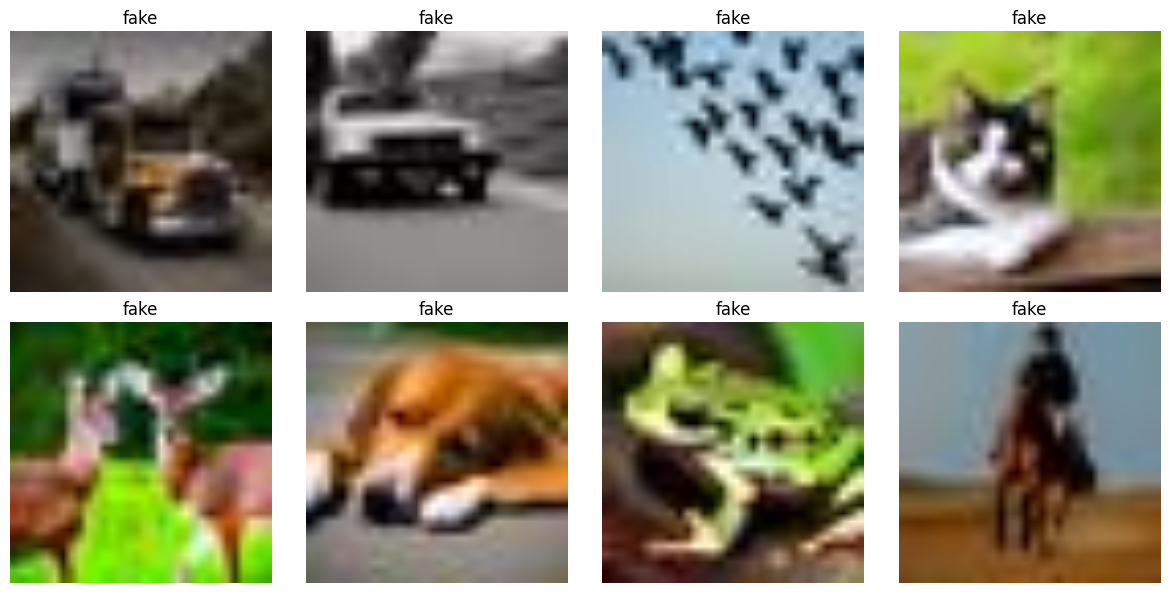

In [13]:
def show_samples(dataset, num_images=8):
    num_images = min(num_images, len(dataset))
    cols = 4
    rows = int(np.ceil(num_images / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)

    mean = np.array(normalize_mean)
    std = np.array(normalize_std)

    for i in range(num_images):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img * std + mean, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(class_names[label])
        axes[i].axis('off')

    for ax in axes[num_images:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(train_dataset)


## Step 9: Check Hardware Availability

The notebook checks whether a CUDA-enabled GPU is available. If a GPU is present, model training will use it for faster computation; otherwise, the CPU will be used.

In [14]:
# Check hardware and build ResNet50 model
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: Runtime is using CPU. In Colab, go to Runtime > Change runtime type > GPU.")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
learning_rate = 1e-4
weight_decay = 1e-4
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

print("Model ready.")


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


Model ready.


## Step 10: Train the ResNet50 Baseline

The model is trained for 10 epochs on the full official CIFAKE training split: 50,000 fake and 50,000 real images. The final model checkpoint is saved after training.

In [15]:
import os

num_epochs = 10
train_losses = []
train_accs = []

best_model_path = str(MODEL_DIR / "resnet50_best_10epochs.pth")
os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

print(f"Starting ResNet50 training for {num_epochs} epochs.", flush=True)
print(f"Each epoch has {len(train_loader)} batches with batch size {batch_size}.", flush=True)

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    running_correct = 0
    seen = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size_now = images.size(0)
        preds = outputs.argmax(dim=1)
        running_train_loss += loss.item() * batch_size_now
        running_correct += (preds == labels).sum().item()
        seen += batch_size_now

        if (batch_idx + 1) % 100 == 0 or (batch_idx + 1) == len(train_loader):
            print(
                f"Epoch {epoch+1}/{num_epochs} "
                f"Batch {batch_idx+1}/{len(train_loader)} "
                f"Loss: {running_train_loss / seen:.4f} "
                f"Acc: {running_correct / seen:.4f}",
                flush=True,
            )

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = running_correct / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} completed - "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Train Acc: {epoch_train_acc:.4f}",
        flush=True,
    )

torch.save(model.state_dict(), best_model_path)
print(f"Training complete. Model saved to {best_model_path}")


Starting ResNet50 training for 10 epochs.


Each epoch has 6250 batches with batch size 16.


Epoch 1/10 Batch 100/6250 Loss: 0.4231 Acc: 0.8144


Epoch 1/10 Batch 200/6250 Loss: 0.3597 Acc: 0.8466


Epoch 1/10 Batch 300/6250 Loss: 0.3291 Acc: 0.8610


...

Epoch 10/10 Batch 6100/6250 Loss: 0.0211 Acc: 0.9923


Epoch 10/10 Batch 6200/6250 Loss: 0.0213 Acc: 0.9923


Epoch 10/10 Batch 6250/6250 Loss: 0.0212 Acc: 0.9923


Epoch 10/10 completed - Train Loss: 0.0212 Train Acc: 0.9923


Training complete. Model saved to .\models\resnet50_best_10epochs.pth


## Step 11: Visualize Training Loss and Accuracy

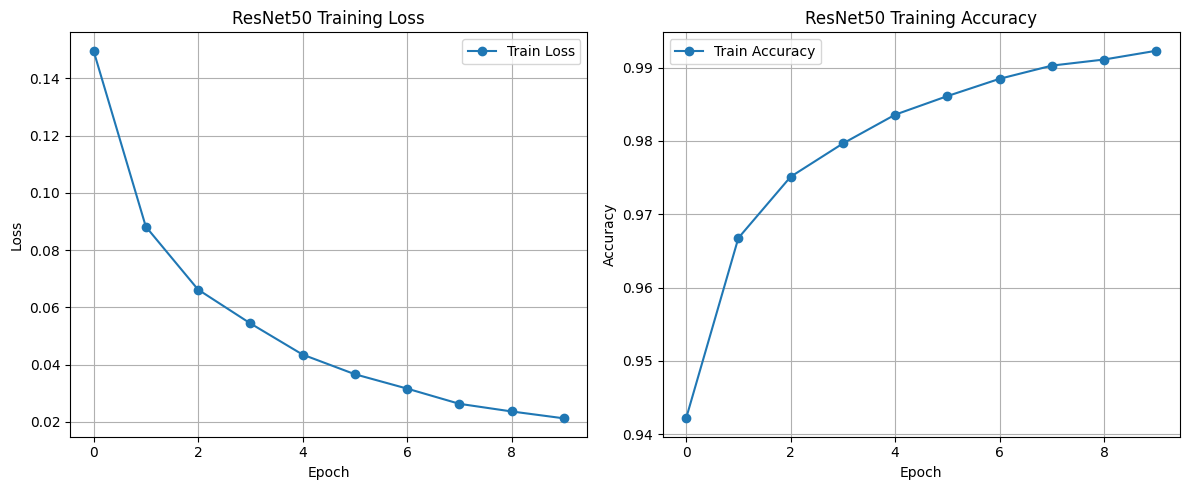

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, marker='o', label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Step 14: Evaluate the Best Model on the Test Set

After training, the best saved model checkpoint is loaded from Google Drive. The trained model is then evaluated on the test dataset. Predictions are generated and compared to the true labels, and standard evaluation metrics are computed, including accuracy, precision, recall, and F1-score.

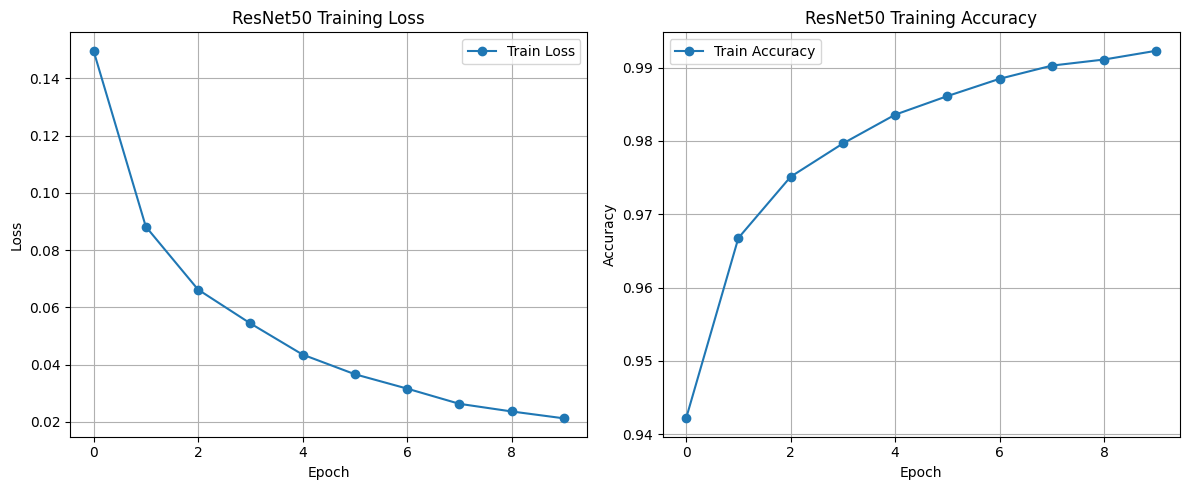

In [17]:
import os

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, marker='o', label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training Accuracy")
plt.legend()
plt.grid(True)

output_dir = str(OUTPUT_DIR)
os.makedirs(output_dir, exist_ok=True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "resnet50_training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 15: Generate the Confusion Matrix

A confusion matrix is created to show how many fake and real images were classified correctly or incorrectly. This provides a more detailed understanding of the model’s prediction behavior.

Test Accuracy: 0.9812
Test Precision: 0.9821  (fake as positive)
Test Recall: 0.9804  (fake as positive)
Test F1-score: 0.9812  (fake as positive)


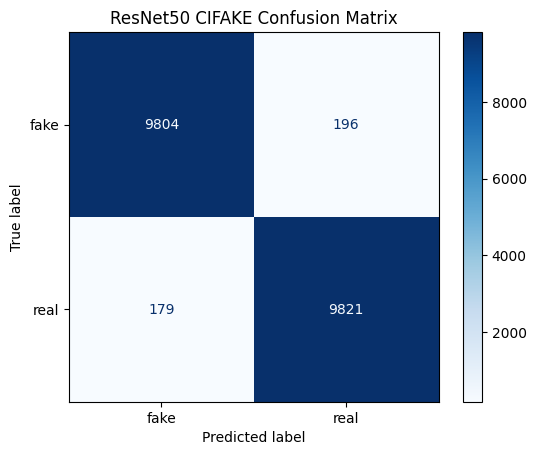

Saved metrics to: .\outputs\resnet50_final_metrics.json


In [18]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, pos_label=0, zero_division=0)
recall = recall_score(all_labels, all_preds, pos_label=0, zero_division=0)
f1 = f1_score(all_labels, all_preds, pos_label=0, zero_division=0)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}  (fake as positive)")
print(f"Test Recall: {recall:.4f}  (fake as positive)")
print(f"Test F1-score: {f1:.4f}  (fake as positive)")

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("ResNet50 CIFAKE Confusion Matrix")
confusion_matrix_path = os.path.join(output_dir, "resnet50_confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

metrics_path = os.path.join(output_dir, "resnet50_final_metrics.json")
metrics = {
    "model": "torchvision.models.resnet50",
    "weights": "DEFAULT ImageNet pretrained",
    "dataset": "official full CIFAKE",
    "class_mapping": {"fake": 0, "real": 1},
    "positive_label_for_precision_recall_f1": "fake",
    "training_config": {
        "batch_size": batch_size,
        "epochs": num_epochs,
        "optimizer": "AdamW",
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "loss": "CrossEntropyLoss",
        "image_size": image_size,
    },
    "history": {
        "train_loss": train_losses,
        "train_accuracy": train_accs,
    },
    "final_test_metrics": {
        "accuracy": float(accuracy),
        "precision_fake_positive": float(precision),
        "recall_fake_positive": float(recall),
        "f1_fake_positive": float(f1),
        "confusion_matrix": cm.tolist(),
    },
    "saved_files": {
        "model_weights": str(best_model_path),
        "training_curves": os.path.join(output_dir, "resnet50_training_curves.png"),
        "confusion_matrix": confusion_matrix_path,
        "metrics_json": metrics_path,
    },
}

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics to:", metrics_path)


## ResNet50 Key Data Points

### Comparison Parameters

- Model: ResNet50 with ImageNet pretrained weights
- Dataset: official full CIFAKE
- Train images: 100,000
- Test images: 20,000
- Image size: 224x224
- Batch size: 16
- Epochs used: 10
- Train batches per epoch: 6,250
- Total training batches: 62,500
- Test batches: 1,250
- Optimizer: AdamW
- Learning rate: 0.0001
- Weight decay: 0.0001
- Loss: CrossEntropyLoss

### Training Results

- Final train loss: 0.0212
- Final train accuracy: 0.9923

### Test Results

- Test accuracy: 0.9812
- Test precision, fake positive: 0.9821
- Test recall, fake positive: 0.9804
- Test F1, fake positive: 0.9812
- Confusion matrix: fake correct 9804, fake predicted real 196, real predicted fake 179, real correct 9821

### Saved Files

- Model weights: `models/resnet50_best_10epochs.pth`
- Training curves: `outputs/resnet50_training_curves.png`
- Confusion matrix: `outputs/resnet50_confusion_matrix.png`
- Metrics JSON: `outputs/resnet50_final_metrics.json`
